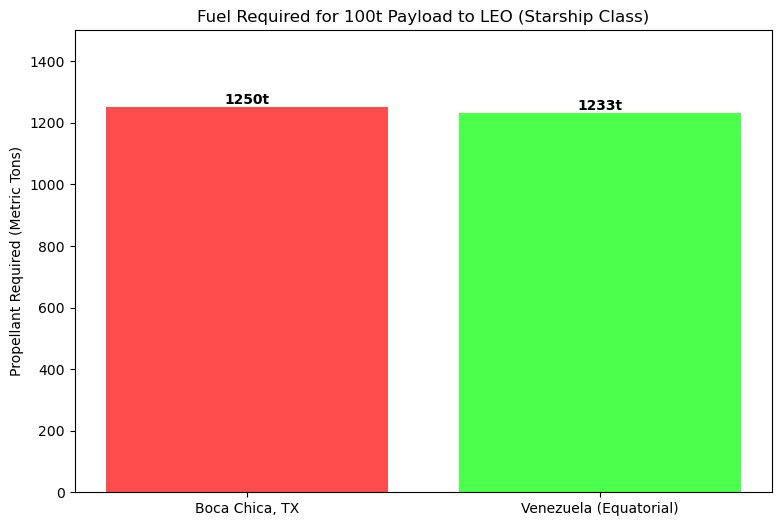

Propellant Saved in Venezuela: 17.33 Metric Tons per launch


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rocket_efficiency_sim():
    # Constants
    EARTH_ROTATION_EQUATOR = 460.0  # meters per second (approx 1,650 km/h)
    LEO_VELOCITY = 7800.0           # velocity needed for orbit (m/s)
    ISP = 380.0                     # Specific Impulse for Raptor engine (vacuum avg)
    G0 = 9.81                       # Gravity constant
    DRY_MASS = 100000.0             # 100 tons (Starship estimate)
    PAYLOAD_MASS = 100000.0         # 100 tons
    
    # Latitudes
    latitudes = {
        "Boca Chica, TX": 26.0,
        "Venezuela (Equatorial)": 5.0
    }
    
    results = {}

    for site, lat in latitudes.items():
        # 1. Calculate Boost from Earth's rotation
        boost = EARTH_ROTATION_EQUATOR * np.cos(np.radians(lat))
        
        # 2. Delta-V remaining to reach orbit
        delta_v_needed = LEO_VELOCITY - boost
        
        # 3. Rocket Equation: m_initial = m_final * exp(delta_v / (Isp * g0))
        # m_final = Dry Mass + Payload
        m_final = DRY_MASS + PAYLOAD_MASS
        m_initial = m_final * np.exp(delta_v_needed / (ISP * G0))
        
        fuel_required = m_initial - m_final
        results[site] = {
            "Boost": boost,
            "Fuel": fuel_required / 1000  # Convert to Metric Tons
        }

    # --- Visualization ---
    sites = list(results.keys())
    fuel_amounts = [results[s]["Fuel"] for s in sites]
    
    plt.figure(figsize=(9, 6))
    bars = plt.bar(sites, fuel_amounts, color=['#ff4d4d', '#4dff4d'])
    plt.title("Fuel Required for 100t Payload to LEO (Starship Class)")
    plt.ylabel("Propellant Required (Metric Tons)")
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, f'{int(yval)}t', ha='center', fontweight='bold')

    plt.ylim(0, max(fuel_amounts) * 1.2)
    plt.show()
    
    # Energy Calculation
    fuel_diff = results["Boca Chica, TX"]["Fuel"] - results["Venezuela (Equatorial)"]["Fuel"]
    print(f"Propellant Saved in Venezuela: {fuel_diff:.2f} Metric Tons per launch")

rocket_efficiency_sim()